In [1]:
# Builds a daily chart for the SF shelter waitlist

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from datetime import datetime
import seaborn as sns
import re

In [3]:
# seaborn styles
sns.set_style("whitegrid")

In [4]:
# compile regex for extracting date
extract_date = re.compile(r'(\d{4}-\d{2}-\d{2})')

In [5]:
df_list = []

for file in glob("waitlist_data/*.csv"):
    day = extract_date.search(file).group(0)
    df = pd.read_csv(file).assign( date = pd.to_datetime(day))
    df_list.append(df)

df = pd.concat(df_list)

df.head(3)


,Position,Waitlist ID,SR #,Instructions,date,data_as_of,data_loaded_at
0,1,07031977AB,18001893,NaN,2024-06-08,NaN,NaN
1,2,06211967RC,18118951,NaN,2024-06-08,NaN,NaN
2,3,12071975RS,18154663,NaN,2024-06-08,NaN,NaN


In [6]:
count_by_day = (
        df
    .assign(
        day = lambda f: f["date"].dt.strftime("%m-%d"),
    )
    .groupby('day')
    ["Waitlist ID"]
    .count()
    .reset_index()
)

count_by_day.head()

,day,Waitlist ID
0,05-16,108
1,05-17,108
2,05-19,101
3,05-20,107
4,05-21,95


<Axes: title={'center': 'Waitlist count by day'}>

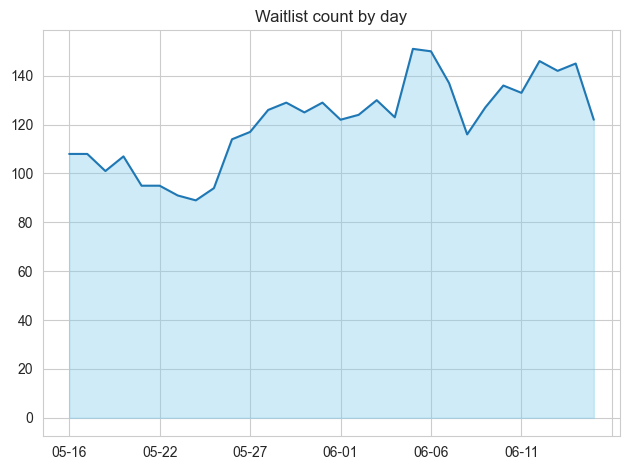

In [7]:
ax = (
    df
    .assign(
        day = lambda f: f["date"].dt.strftime("%m-%d"),
    )
    .groupby('day')
    ["Waitlist ID"]
    .count()
    .plot(
        kind = "line",
        # rotate ticks
        rot = 0,
        title = "Waitlist count by day",
        xlabel=""
    )
)

plt.fill_between(count_by_day['day'], count_by_day['Waitlist ID'], color='skyblue', alpha=0.4)

# # Get the total number of x-ticks
tick_labs = [each.get_text() for each in ax.get_xticklabels()]
total_ticks = len(tick_labs)
# # Only show every 5th tick but also show the last
# ax.set_xticks(range(0, total_ticks, 5))

fig = ax.get_figure()
fig.tight_layout()
fig.savefig("images/waitlist_count_by_day.png")
ax

---
---
---